# Análisis de Resultados

Objetivo: evaluar en profundidad los modelos seleccionados en la etapa de entrenamiento — uno por experimento — usando el dataset de trabajo.

Se analizan las matrices de confusión, las curvas ROC y Precision-Recall, la importancia de variables y el comportamiento del modelo ante distintos umbrales de clasificación.

## 1. Importar paquetes

In [3]:
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate, learning_curve
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    classification_report, f1_score
)
warnings.filterwarnings('ignore')

## 2. Rutas y carga de artefactos

Se resuelve la raíz del repositorio y se cargan los datasets preprocesados junto con los modelos entrenados en la etapa anterior.

In [2]:

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'README.md').exists():
    repo_root = repo_root.parent

if not (repo_root / 'README.md').exists():
    raise FileNotFoundError('No se encontró la raíz del repositorio (README.md).')

datos_dir      = repo_root / '02_Datos' / '03_Trabajo'
modelos_dir    = repo_root / '04_Modelos'
resultados_dir = repo_root / '05_Resultados'
resultados_dir.mkdir(parents=True, exist_ok=True)

print(f'Raíz del repositorio : {repo_root}')
print(f'Datos                : {datos_dir}')
print(f'Modelos              : {modelos_dir}')


Raíz del repositorio : C:\Github\Asteroid_Classification
Datos                : C:\Github\Asteroid_Classification\02_Datos\03_Trabajo
Modelos              : C:\Github\Asteroid_Classification\04_Modelos


In [3]:

with open(datos_dir / 'trabajo_preprocesado_moid.pickle', 'rb') as f:
    df_moid = pickle.load(f)

with open(datos_dir / 'trabajo_preprocesado.pickle', 'rb') as f:
    df_nomoid = pickle.load(f)

print(f'df_moid  : {df_moid.shape}')
print(f'df_nomoid: {df_nomoid.shape}')

df_moid  : (88292, 28)
df_nomoid: (88292, 27)


In [4]:
# Separación features / target
X_moid,   y_moid   = df_moid.drop(columns=['pha']),   df_moid['pha']
X_nomoid, y_nomoid = df_nomoid.drop(columns=['pha']), df_nomoid['pha']

# Cargar modelos — los nombres se resuelven dinámicamente desde 04_Modelos/
modelos_a = sorted(modelos_dir.glob('*_pha_A_v1_pipeline.joblib'))
modelos_b = sorted(modelos_dir.glob('*_pha_B_v1_pipeline.joblib'))

if not modelos_a or not modelos_b:
    raise FileNotFoundError('No se encontraron modelos en 04_Modelos/. Ejecutar 05_Entrenamiento primero.')

modelo_a = joblib.load(modelos_a[0])
modelo_b = joblib.load(modelos_b[0])

print(f'Modelo A: {modelos_a[0].name}')
print(f'Modelo B: {modelos_b[0].name}')

Modelo A: rfc_pha_A_v1_pipeline.joblib
Modelo B: xgb_pha_B_v1_pipeline.joblib


## 3. Validación cruzada estratificada

Se define el mismo `cv` utilizado en entrenamiento para garantizar que las métricas sean comparables.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 2. Importancia de variables

Se analiza la contribución de cada feature al modelo ganador de cada experimento. El método varía según el algoritmo:

- **Random Forest / XGBoost**: `feature_importances_` — reducción media de impureza (Gini) acumulada sobre todos los árboles.
- **Logistic Regression**: valor absoluto de los coeficientes estandarizados — magnitud del efecto sobre el log-odds.

La comparación entre Experimento A y B permite identificar qué variables asumieron el rol de `moid` cuando esta fue excluida.

In [6]:
def get_importancias(modelo, feature_names):
    """Devuelve DataFrame con importancia normalizada por tipo de modelo."""
    nombre = type(modelo).__name__
    if hasattr(modelo, 'feature_importances_'):
        imp = modelo.feature_importances_
    elif hasattr(modelo, 'coef_'):
        imp = np.abs(modelo.coef_[0])
        imp = imp / imp.sum()  # normalizar para comparar con árbol
    else:
        raise ValueError(f'Modelo {nombre} no tiene feature_importances_ ni coef_')

    df = pd.DataFrame({'feature': feature_names, 'importancia': imp})
    df = df.sort_values('importancia', ascending=False).reset_index(drop=True)
    return df

In [7]:
imp_a = get_importancias(modelo_a, X_moid.columns.tolist())
imp_b = get_importancias(modelo_b, X_nomoid.columns.tolist())

print('=== Top 10 — Experimento A ===')
print(imp_a.head(10).to_string(index=False))
print()
print('=== Top 10 — Experimento B ===')
print(imp_b.head(10).to_string(index=False))

=== Top 10 — Experimento A ===
  feature  importancia
     moid     0.216153
        q     0.212352
    class     0.145106
        a     0.101497
 diameter     0.069015
        e     0.061927
 sigma_tp     0.054509
        H     0.038036
sigma_per     0.036386
  sigma_q     0.020086

=== Top 10 — Experimento B ===
 feature  importancia
       q     0.721991
       a     0.161903
   class     0.047885
sigma_tp     0.027126
       e     0.024746
       H     0.006068
sigma_ma     0.001798
 sigma_a     0.001334
 sigma_q     0.000976
diameter     0.000678


In [ ]:
top_n = 15
imp_plot = imp_a.head(top_n)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_plot['feature'][::-1], imp_plot['importancia'][::-1], color='#4C72B0')
ax.set_xlabel('Importancia relativa')
ax.set_title(f'Top {top_n} variables — Experimento A (con moid)')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig(resultados_dir / 'importancia_variables_A.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
imp_plot = imp_b.head(top_n)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_plot['feature'][::-1], imp_plot['importancia'][::-1], color='#55A868')
ax.set_xlabel('Importancia relativa')
ax.set_title(f'Top {top_n} variables — Experimento B (sin moid)')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig(resultados_dir / 'importancia_variables_B.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.1 Comparación de importancias entre experimentos

Se cruzan las importancias de ambos experimentos para las variables compartidas. Si en el Experimento B las variables `q`, `a` y `e` suben en el ranking respecto al Experimento A, es evidencia de que el modelo aprendió las variables físicas que determinan el MOID — no la etiqueta directamente.

In [9]:
# Variables presentes en ambos experimentos
vars_comunes = [f for f in X_nomoid.columns if f in X_moid.columns]

imp_a_comun = imp_a[imp_a['feature'].isin(vars_comunes)].set_index('feature')['importancia']
imp_b_comun = imp_b[imp_b['feature'].isin(vars_comunes)].set_index('feature')['importancia']

df_comp = pd.DataFrame({
    'Exp A': imp_a_comun,
    'Exp B': imp_b_comun,
}).dropna().sort_values('Exp B', ascending=False)

df_comp['Delta (B - A)'] = (df_comp['Exp B'] - df_comp['Exp A']).round(4)
df_comp = df_comp.round(4)
print('Variables comunes — importancia por experimento (ordenadas por Exp B):')
print(df_comp.to_string())

Variables comunes — importancia por experimento (ordenadas por Exp B):
                 Exp A   Exp B  Delta (B - A)
feature                                      
q               0.2124  0.7220         0.5096
a               0.1015  0.1619         0.0604
class           0.1451  0.0479        -0.0972
sigma_tp        0.0545  0.0271        -0.0274
e               0.0619  0.0247        -0.0372
H               0.0380  0.0061        -0.0320
sigma_ma        0.0009  0.0018         0.0009
sigma_a         0.0081  0.0013        -0.0068
sigma_q         0.0201  0.0010        -0.0191
diameter        0.0690  0.0007        -0.0683
rms             0.0063  0.0005        -0.0057
tp_cal          0.0003  0.0004         0.0001
sigma_n         0.0025  0.0004        -0.0020
diameter_sigma  0.0076  0.0004        -0.0072
sigma_om        0.0021  0.0004        -0.0016
sigma_e         0.0006  0.0004        -0.0002
tp              0.0001  0.0004         0.0002
sigma_ad        0.0076  0.0003        -0.0073
sigma_per

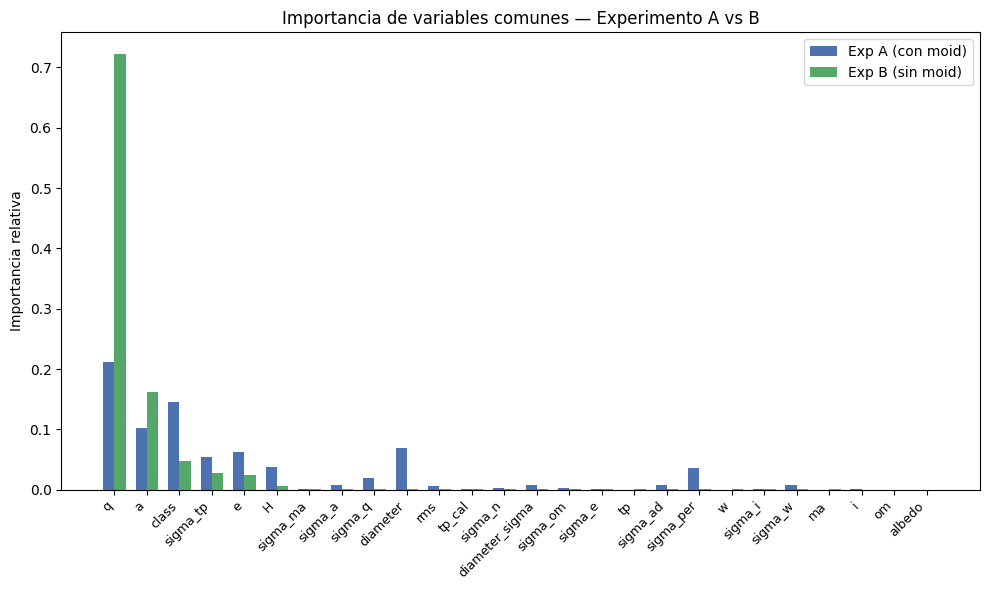

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(df_comp))
width = 0.35
ax.bar([i - width/2 for i in x], df_comp['Exp A'], width, label='Exp A (con moid)', color='#4C72B0')
ax.bar([i + width/2 for i in x], df_comp['Exp B'], width, label='Exp B (sin moid)', color='#55A868')

ax.set_xticks(list(x))
ax.set_xticklabels(df_comp.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Importancia relativa')
ax.set_title('Importancia de variables comunes — Experimento A vs B')
ax.legend()

plt.tight_layout()
plt.savefig(resultados_dir / 'importancia_comparacion_AB.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Impacto de `moid`

Se cuantifica cuánto influyó `moid` en las métricas del Experimento A. `moid < 0.05 UA` forma parte de la definición formal de PHA — incluirlo como feature introduce una tautología: el modelo puede aprender la etiqueta directamente desde la variable que la define, produciendo métricas infladas que no reflejan capacidad predictiva real.

El Experimento B (sin `moid`) es el punto de referencia para medir el poder predictivo genuino de las variables físicas orbitales.

In [11]:

scoring = {'f1': 'f1', 'roc_auc': 'roc_auc', 'average_precision': 'average_precision'}

print('Evaluando Experimento A...')
cv_a = cross_validate(modelo_a, X_moid,   y_moid,   cv=cv, scoring=scoring, n_jobs=-1)

print('Evaluando Experimento B...')
cv_b = cross_validate(modelo_b, X_nomoid, y_nomoid, cv=cv, scoring=scoring, n_jobs=-1)

print('Listo.')

Evaluando Experimento A...
Evaluando Experimento B...
Listo.


In [12]:
metricas_labels = {
    'test_f1':                'F1',
    'test_roc_auc':           'AUC-ROC',
    'test_average_precision': 'Avg Precision',
}

rows = []
for key, label in metricas_labels.items():
    a_mean, a_std = cv_a[key].mean(), cv_a[key].std()
    b_mean, b_std = cv_b[key].mean(), cv_b[key].std()
    delta = b_mean - a_mean
    rows.append({
        'Métrica':  label,
        'Exp A (con moid)': f'{a_mean:.4f} ± {a_std:.4f}',
        'Exp B (sin moid)': f'{b_mean:.4f} ± {b_std:.4f}',
        'Delta (B - A)':    f'{delta:+.4f}',
    })

df_impacto = pd.DataFrame(rows).set_index('Métrica')
print(df_impacto.to_string())

              Exp A (con moid) Exp B (sin moid) Delta (B - A)
Métrica                                                      
F1             0.9953 ± 0.0093  0.6156 ± 0.0633       -0.3798
AUC-ROC        1.0000 ± 0.0000  0.9976 ± 0.0038       -0.0024
Avg Precision  0.9897 ± 0.0206  0.6690 ± 0.0701       -0.3207


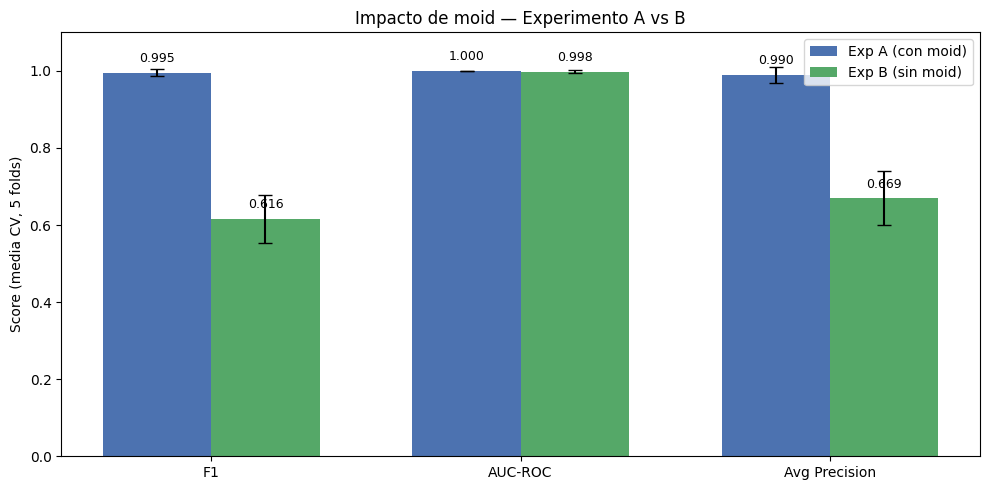

In [13]:
metricas_plot = list(metricas_labels.keys())
labels        = list(metricas_labels.values())

medias_a = [cv_a[m].mean() for m in metricas_plot]
stds_a   = [cv_a[m].std()  for m in metricas_plot]
medias_b = [cv_b[m].mean() for m in metricas_plot]
stds_b   = [cv_b[m].std()  for m in metricas_plot]

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_a = ax.bar(x - width/2, medias_a, width, yerr=stds_a, capsize=5,
                label='Exp A (con moid)', color='#4C72B0')
bars_b = ax.bar(x + width/2, medias_b, width, yerr=stds_b, capsize=5,
                label='Exp B (sin moid)', color='#55A868')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score (media CV, 5 folds)')
ax.set_title('Impacto de moid — Experimento A vs B')
ax.legend()

for bar in list(bars_a) + list(bars_b):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.3f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(resultados_dir / 'impacto_moid.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.1 Interpretación

La diferencia entre los scores de ambos experimentos cuantifica el efecto de la tautología:

- **Delta cercano a cero**: `moid` aportó poco — las variables físicas (`q`, `a`, `e`) ya eran suficientes para separar PHA. El modelo B es igualmente válido para producción.
- **Delta negativo grande (B << A)**: `moid` era determinante — el modelo A aprendió la definición de la etiqueta, no los patrones físicos subyacentes. En ese caso el Experimento B es el único candidato confiable para producción.

Complementar con los resultados de la Sección 2: si en Exp B las variables `q`, `a` y `e` tienen alta importancia, el modelo capturó la física orbital que subyace al criterio MOID < 0.05 UA.

In [14]:
vars_fisicas_clave = ['q', 'a', 'e', 'H', 'i']
presentes = [v for v in vars_fisicas_clave if v in imp_b['feature'].values]

print('Ranking de variables físicas clave en Experimento B:')
print(f'{"Variable":<10} {"Ranking":<10} {"Importancia"}')
print('-' * 35)
for var in presentes:
    rank = imp_b[imp_b['feature'] == var].index[0] + 1
    imp_val = imp_b[imp_b['feature'] == var]['importancia'].values[0]
    print(f'{var:<10} {rank:<10} {imp_val:.4f}')

Ranking de variables físicas clave en Experimento B:
Variable   Ranking    Importancia
-----------------------------------
q          1          0.7220
a          2          0.1619
e          5          0.0247
H          6          0.0061
i          24         0.0002


## 4. Overfitting / Underfitting

Se usan curvas de aprendizaje (`learning_curve`) para diagnosticar el ajuste de cada modelo. La curva compara el F1 en entrenamiento vs. validación cruzada a medida que aumenta el tamaño del conjunto de entrenamiento:

| Patrón | Diagnóstico |
|--------|-------------|
| Score train alto, score CV bajo, brecha amplia | **Overfitting** — el modelo memoriza, no generaliza |
| Ambos scores bajos y convergentes | **Underfitting** — el modelo no captura la señal |
| Ambos scores altos y convergentes | **Buen ajuste** |

El RFC del Experimento A (F1 CV = 0.9953) es el caso de mayor interés: una brecha train/CV mínima indicaría que el score es genuino; una brecha grande confirmaría overfitting por tautología con `moid`.

In [1]:
def plot_learning_curve(modelo, X, y, cv, titulo, color, ruta_guardado):
    train_sizes, train_scores, val_scores = learning_curve(
        modelo, X, y,
        cv=cv,
        scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(train_sizes, train_mean, 'o-', color=color,       label='Train F1')
    ax.plot(train_sizes, val_mean,   's--', color='#C44E52',  label='CV F1 (validación)')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color=color)
    ax.fill_between(train_sizes, val_mean - val_std,     val_mean + val_std,     alpha=0.15, color='#C44E52')
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('F1 (clase PHA)')
    ax.set_ylim(0, 1.05)
    ax.set_title(titulo)
    ax.legend(loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig(ruta_guardado, dpi=150, bbox_inches='tight')
    plt.show()

    brecha_final = train_mean[-1] - val_mean[-1]
    print(f'Train F1 final : {train_mean[-1]:.4f} ± {train_std[-1]:.4f}')
    print(f'CV F1 final    : {val_mean[-1]:.4f} ± {val_std[-1]:.4f}')
    print(f'Brecha         : {brecha_final:.4f}')
    return brecha_final

### 4.1 Experimento A (con `moid`)

In [2]:
brecha_a = plot_learning_curve(
    modelo_a, X_moid, y_moid, cv,
    titulo='Curva de aprendizaje — Experimento A (con moid)',
    color='#4C72B0',
    ruta_guardado=resultados_dir / 'learning_curve_A.png'
)

NameError: name 'modelo_a' is not defined

### 4.2 Experimento B (sin `moid`)

In [ ]:
brecha_b = plot_learning_curve(
    modelo_b, X_nomoid, y_nomoid, cv,
    titulo='Curva de aprendizaje — Experimento B (sin moid)',
    color='#55A868',
    ruta_guardado=resultados_dir / 'learning_curve_B.png'
)

In [ ]:
print('=== Diagnóstico comparativo ===')
for exp, brecha in [('A (con moid)', brecha_a), ('B (sin moid)', brecha_b)]:
    if brecha > 0.10:
        diagnostico = 'OVERFITTING — brecha train/CV > 0.10'
    elif brecha < 0.02:
        diagnostico = 'Buen ajuste — brecha mínima'
    else:
        diagnostico = 'Ajuste aceptable — brecha moderada'
    print(f'  Exp {exp}: brecha={brecha:.4f} → {diagnostico}')